#Setup

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import keras
from keras.models import Model
from keras.layers import Input, Dense, LSTM, concatenate, Activation, MaxPool1D, Flatten
from keras.layers import Conv1D, BatchNormalization, GlobalAveragePooling1D, Permute, Dropout, Bidirectional
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Data Incertion

In [ ]:
# Data incerted
raw_data = np.loadtxt('/content/drive/MyDrive/Exoplanet_Detect/exoTrain.csv', skiprows=1, delimiter=',')
X_train = raw_data[:, 1:]
y_train = raw_data[:, 0, np.newaxis] - 1.
raw_data = np.loadtxt('/content/drive/MyDrive/Exoplanet_Detect/exoTest.csv', skiprows=1, delimiter=',')
X_test = raw_data[:, 1:]
y_test = raw_data[:, 0, np.newaxis] - 1.
#del raw_data

In [ ]:
pd.read_csv('/content/drive/MyDrive/Exoplanet_Detect/exoTest.csv').head(10)

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,119.88,100.21,86.46,48.68,46.12,39.39,18.57,6.98,6.63,...,14.52,19.29,14.44,-1.62,13.33,45.50,31.93,35.78,269.43,57.72
1,2,5736.59,5699.98,5717.16,5692.73,5663.83,5631.16,5626.39,5569.47,5550.44,...,-581.91,-984.09,-1230.89,-1600.45,-1824.53,-2061.17,-2265.98,-2366.19,-2294.86,-2034.72
2,2,844.48,817.49,770.07,675.01,605.52,499.45,440.77,362.95,207.27,...,17.82,-51.66,-48.29,-59.99,-82.10,-174.54,-95.23,-162.68,-36.79,30.63
3,2,-826.00,-827.31,-846.12,-836.03,-745.50,-784.69,-791.22,-746.50,-709.53,...,122.34,93.03,93.03,68.81,9.81,20.75,20.25,-120.81,-257.56,-215.41
4,2,-39.57,-15.88,-9.16,-6.37,-16.13,-24.05,-0.90,-45.20,-5.04,...,-37.87,-61.85,-27.15,-21.18,-33.76,-85.34,-81.46,-61.98,-69.34,-17.84
5,1,14.28,10.63,14.56,12.42,12.07,12.92,12.27,3.19,8.47,...,3.86,-4.06,-3.56,-1.13,-7.18,-4.78,-4.34,7.67,-0.33,-7.53
6,1,-150.48,-141.72,-157.60,-184.60,-164.89,-173.87,-162.91,-167.04,-172.76,...,7.15,5.16,-9.08,-39.11,-32.31,-8.40,-16.80,-8.03,-12.73,-11.41
7,1,-10.06,-12.78,-13.16,-9.81,-18.91,-20.33,-22.85,-19.17,-17.97,...,21.49,30.63,24.19,33.00,35.70,35.89,-33.44,-30.83,-33.00,-20.15
8,1,454.66,440.60,382.29,361.63,298.63,253.29,155.86,110.38,31.71,...,-56.78,-61.64,-120.32,-65.39,-126.75,-78.18,-184.39,-142.31,-113.12,-111.78
9,1,187.40,209.60,199.91,179.62,171.21,161.84,163.02,171.61,113.53,...,-23.75,-35.72,-21.93,-16.47,-21.84,-26.64,-13.90,17.03,4.36,2.91


In [ ]:
X_train,X_train.shape

(array([[ 93.85,  83.81,  20.1 , ...,  61.42,   5.08, -39.54],
        [-38.88, -33.83, -58.54, ...,   6.46,  16.  ,  19.93],
        [532.64, 535.92, 513.73, ..., -28.91, -70.02, -96.67],
        ...,
        [273.39, 278.  , 261.73, ...,  88.42,  79.07,  79.43],
        [  3.82,   2.09,  -3.29, ..., -14.55,  -6.41,  -2.55],
        [323.28, 306.36, 293.16, ..., -16.72, -14.09,  27.82]]),
 (5087, 3197))

# Data Visualization

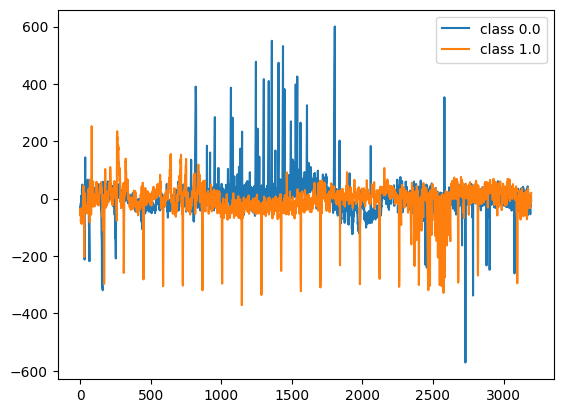

In [ ]:
classes = np.unique(np.concatenate((y_train, y_test), axis=0))

plt.figure()
for c in classes:
    c_x_train = X_train[y_train[:, 0] == c]
    plt.plot(c_x_train[1], label="class " + str(c))
plt.legend(loc="best")
plt.show()
plt.close()

# Visualizing Class Imbalance

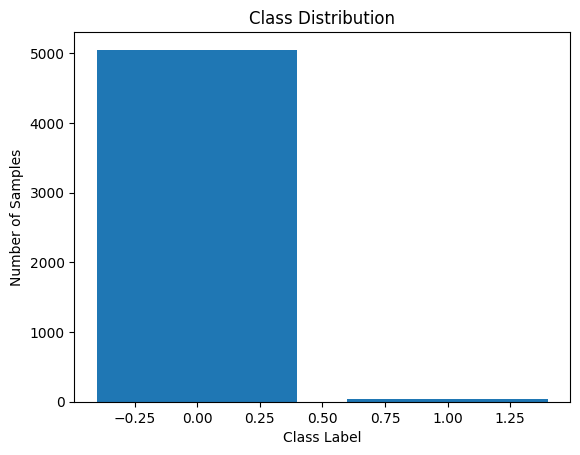

In [ ]:
import matplotlib.pyplot as plt

# Calculate class distribution
class_counts = np.bincount(y_train.flatten().astype(int))

# Plot class distribution
plt.bar(np.unique(y_train.flatten()), class_counts)
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.title('Class Distribution')
plt.show()


In [ ]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import OneSidedSelection
from imblearn.pipeline import Pipeline

# Define a pipeline for SMOTE + OSS
smote_oss_pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy=0.20, k_neighbors=5)),
    ('oss', OneSidedSelection(n_neighbors=5, n_seeds_S=1500))
])

# Apply the pipeline to your data
X_train_smote_oss, y_train_smote_oss = smote_oss_pipeline.fit_resample(X_train, y_train)

# Define a pipeline for ADASYN + OSS
adasyn_oss_pipeline = Pipeline([
    ('adasyn', ADASYN(sampling_strategy=0.20, n_neighbors=5)),
    ('oss', OneSidedSelection(n_neighbors=5, n_seeds_S=1500))
])

# Apply the pipeline to your data
X_train_adasyn_oss, y_train_adasyn_oss = adasyn_oss_pipeline.fit_resample(X_train, y_train)

#Data after Oversampling and Undersampling

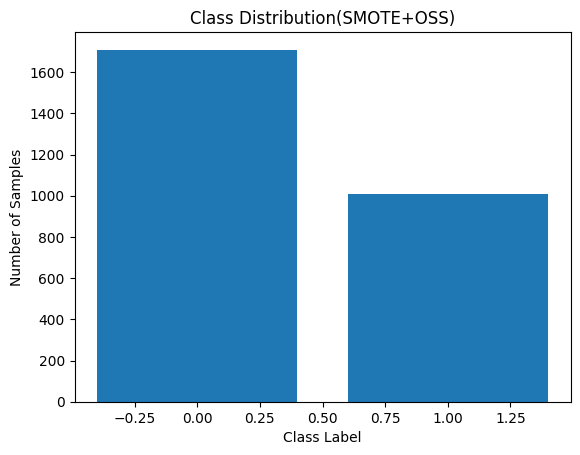

In [ ]:
import matplotlib.pyplot as plt

# Calculate class distribution
class_counts = np.bincount(y_train_smote_oss.flatten().astype(int))

# Plot class distribution
plt.bar(np.unique(y_train_smote_oss.flatten()), class_counts)
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.title('Class Distribution(SMOTE+OSS)')
plt.show()


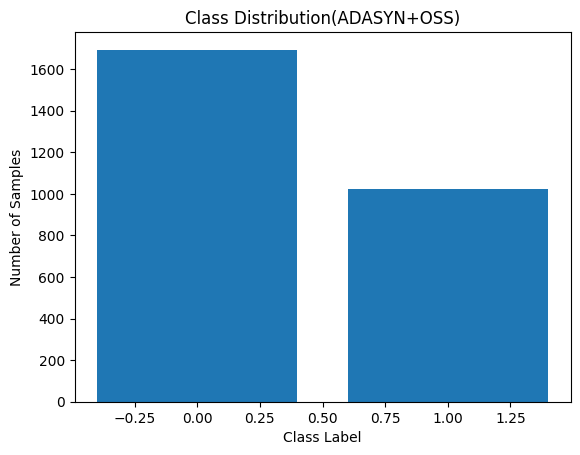

In [ ]:
import matplotlib.pyplot as plt

# Calculate class distribution
class_counts = np.bincount(y_train_adasyn_oss.flatten().astype(int))

# Plot class distribution
plt.bar(np.unique(y_train_adasyn_oss.flatten()), class_counts)
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.title('Class Distribution(ADASYN+OSS)')
plt.show()

# Using ADASYN + OSS





In [ ]:
X_train, y_train = X_train_adasyn_oss, y_train_adasyn_oss

# Normalizing the data
Our timeseries are already in a single length (500). However, their values are usually in various ranges. This is not ideal for a neural network; in general we should seek to make the input values normalized. For this specific dataset, the data is already z-normalized: each timeseries sample has a mean equal to zero and a standard deviation equal to one. This type of normalization is very common for timeseries classification problems, see Bagnall et al. (2016).

Note that the timeseries data used here are univariate, meaning we only have one channel per timeseries example. We will therefore transform the timeseries into a multivariate one with one channel using a simple reshaping via numpy. This will allow us to construct a model that is easily applicable to multivariate time series. (**Coppied Needs to e Updated**)

In [ ]:
''' Normalizing the training and testing data features
    (x_train and x_test) using z-score normalization, also known
    as standardization.
'''

X_train = ((X_train - np.mean(X_train, axis=1).reshape(-1,1)) /
           np.std(X_train, axis=1).reshape(-1,1))
X_test = ((X_test - np.mean(X_test, axis=1).reshape(-1,1)) /
          np.std(X_test, axis=1).reshape(-1,1))

# Reshaping The Data

In [ ]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
x_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

Finally, in order to use sparse_categorical_crossentropy, we will have to count the number of classes beforehand.

In [ ]:
num_classes = len(np.unique(y_train))

Now we shuffle the training set because we will be using the validation_split option later when training.

In [ ]:
idx = np.random.permutation(len(X_train))
X_train = X_train[idx]
y_train = y_train[idx]

In [ ]:
X_test.shape

(570, 3197)

# Build a Model

In [ ]:
def fcn_model(input_shape):
    input_layer = keras.layers.Input(input_shape)

    conv1 = keras.layers.Conv1D(filters=128, kernel_size=3, padding="same")(input_layer)
    conv1 = keras.layers.BatchNormalization()(conv1)
    conv1 = keras.layers.ReLU()(conv1)

    conv2 = keras.layers.Conv1D(filters=256, kernel_size=3, padding="same")(conv1)
    conv2 = keras.layers.BatchNormalization()(conv2)
    conv2 = keras.layers.ReLU()(conv2)

    conv3 = keras.layers.Conv1D(filters=128, kernel_size=3, padding="same")(conv2)
    conv3 = keras.layers.BatchNormalization()(conv3)
    conv3 = keras.layers.ReLU()(conv3)

    gap = keras.layers.GlobalAveragePooling1D()(conv3)

    out = keras.layers.Dropout(0.2)(gap)
    #output_layer = keras.layers.Dense(num_classes, activation="softmax")(gap)
    hidden_layer=
    return out#keras.models.Model(inputs=input_layer, outputs=output_layer)


model_fcn = fcn_model(input_shape=X_train.shape[1:])
#keras.utils.plot_model(model, show_shapes=True)
#model_fcn.summary()


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers

def lstm_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)
    x = layers.LSTM(64, return_sequences=True)(inputs)
    #x = layers.Dropout(0.2)(x)
    x = layers.LSTM(128, return_sequences=True)(x)
    #x = layers.Dropout(0.2)(x)
    x = (layers.LSTM(128))(x)
    #x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.25)(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model


# Example usage:
model_lstm = lstm_model(input_shape=X_train.shape[1:], num_classes=num_classes)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
input_shape=X_train.shape[1:]
def lstm_model(input_shape):
    model = tf.keras.Sequential([
        layers.Bidirectional(layers.LSTM(64, return_sequences=True), input_shape=input_shape),
        layers.Dropout(0.2),
        layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
        layers.Dropout(0.2),
        layers.Bidirectional(layers.LSTM(128)),
        layers.Dropout(0.2),
        layers.Dense(2, activation='softmax')])
    return model
# Example usage:
#input_shape = (input_shape, num_features)  # Define your input shape
model = lstm_model(input_shape)

In [ ]:
#Concatenate
x = concatenate([model_fcn, model_lstm])
x = Dense(32, activation='relu')(x)
out = Dense(1, activation='sigmoid')(x)
model_cnn_lstm = Model(tf.keras.input=input_shape, out)
model_cnn_lstm.summary()

ValueError: Found unexpected instance while processing input tensors for keras functional model. Expecting KerasTensor which is from tf.keras.Input() or output from keras layer call(). Got: 3197

In [ ]:
keras.utils.plot_model(model, show_shapes=True)

NameError: name 'model' is not defined

In [ ]:
#resnet
import tensorflow as tf
from tensorflow.keras import layers

def convolutional_block(x, filters, kernel_size=3):
    y = layers.Conv1D(filters, kernel_size, padding='same')(x)
    y = layers.BatchNormalization()(y)
    y = layers.ReLU()(y)
    return y

def residual_blocks(x, filters, num_blocks):
    for _ in range(num_blocks):
        x = convolutional_block(x, filters)
    return x

def resnet(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)

    # Initial convolutional layer
    x = layers.Conv1D(64, 7, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(3, strides=2, padding='same')(x)

    # Residual blocks
    x = residual_blocks(x, 64, 3)
    x = residual_blocks(x, 128, 3)
    x = residual_blocks(x, 128, 3)

    # Global average pooling and output
    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)

# Example usage:
input_shape = X_train.shape[1:]  # Define your input shape
num_classes = 2  # Define the number of classes
model = resnet(input_shape, num_classes)


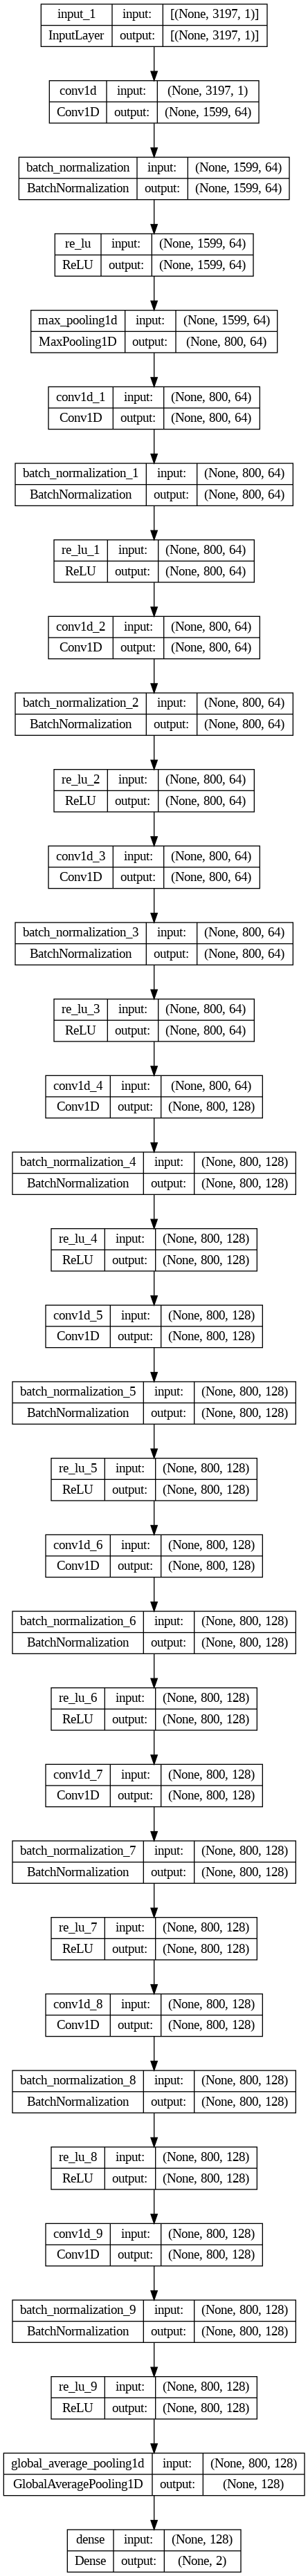

In [ ]:
keras.utils.plot_model(model, show_shapes=True)

In [ ]:
X_train.shape

(2721, 3197, 1)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
                                                stratify=y_train,
                                                test_size=0.25)

In [ ]:
X_train.shape

(2040, 3197, 1)

# Train the model

In [ ]:
epochs = 100
batch_size = 32
EarlyStopping=keras.callbacks.EarlyStopping(verbose=1, patience=20, monitor="val_accuracy", mode="max",restore_best_weights=True)

# callbacks = [
#     keras.callbacks.ModelCheckpoint(
#         "best_model.keras", save_best_only=True, monitor="val_loss"
#     ),
#     keras.callbacks.ReduceLROnPlateau(
#         monitor="val_loss", factor=0.5, patience=20, min_lr=0.0001
#     ),
#     keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, verbose=1),
# ]
model_lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model_lstm.fit(
    X_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[EarlyStopping],
    #validation_split=0.2
    validation_data=(X_val,y_val)
)

Epoch 1/100
60/60 [==============================] - 28s 373ms/step - loss: 0.6048 - accuracy: 0.6921 - val_loss: 0.5774 - val_accuracy: 0.7183
Epoch 2/100
60/60 [==============================] - 19s 307ms/step - loss: 0.4945 - accuracy: 0.7638 - val_loss: 0.4115 - val_accuracy: 0.8180
Epoch 3/100
60/60 [==============================] - 19s 317ms/step - loss: 0.4381 - accuracy: 0.8023 - val_loss: 0.4334 - val_accuracy: 0.8118
Epoch 4/100
60/60 [==============================] - 18s 308ms/step - loss: 0.3594 - accuracy: 0.8487 - val_loss: 0.3076 - val_accuracy: 0.8696
Epoch 5/100
60/60 [==============================] - 19s 310ms/step - loss: 0.3529 - accuracy: 0.8419 - val_loss: 0.3424 - val_accuracy: 0.8499
Epoch 6/100
60/60 [==============================] - 21s 348ms/step - loss: 0.3068 - accuracy: 0.8698 - val_loss: 0.3239 - val_accuracy: 0.8573
Epoch 7/100
60/60 [==============================] - 19s 309ms/step - loss: 0.3077 - accuracy: 0.8693 - val_loss: 0.2869 - val_accuracy:

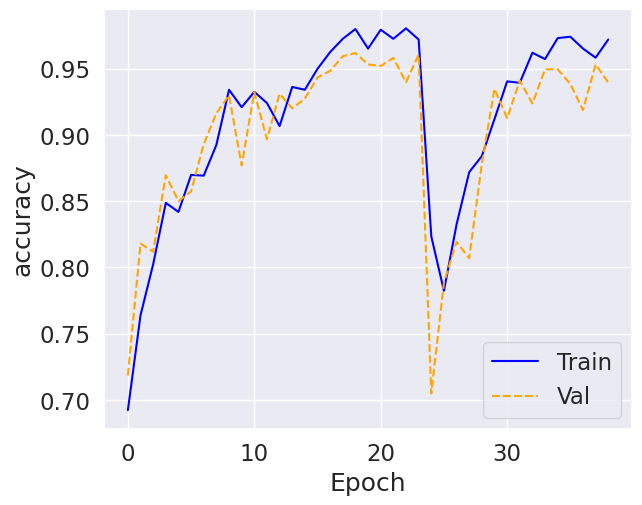

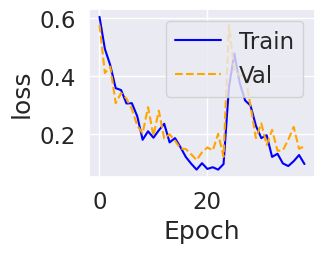

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

colors = ['blue','orange']
plt.figure(figsize=(15, 12))
metrics = ['accuracy', 'loss']

for i, metric in enumerate(metrics):
    plt.subplot(220 + 1 + i)
    plt.plot(history.epoch, history.history[metric], color=colors[0], label='Train')
    plt.plot(history.epoch, history.history['val_' + metric],
                color=colors[1], linestyle="--", label='Val')
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.legend()
    plt.show()

In [ ]:
y_pred_indices.shape

(570, 2)

In [ ]:
# Get the predicted class indices using model.predict and np.argmax
y_pred_indices = model_lstm.predict(x_test)
import numpy as np

# Assuming y_pred_indices is a numpy array with continuous values
# Thresholding operation: if less than 0.5, set to 0; otherwise, set to 1
y_pred_binary = np.where(y_pred_indices < 0.5, 0, 1)

# Get the class names from the y_train dataset
class_names=['Non-exoplanet','Exoplanet']

# Generate and print the classification report
print(classification_report(y_test, y_pred_binary, target_names=class_names))

18/18 [==============================] - 36s 111ms/step
               precision    recall  f1-score   support

Non-exoplanet       0.99      0.95      0.97       565
    Exoplanet       0.00      0.00      0.00         5

     accuracy                           0.94       570
    macro avg       0.50      0.48      0.49       570
 weighted avg       0.98      0.94      0.96       570



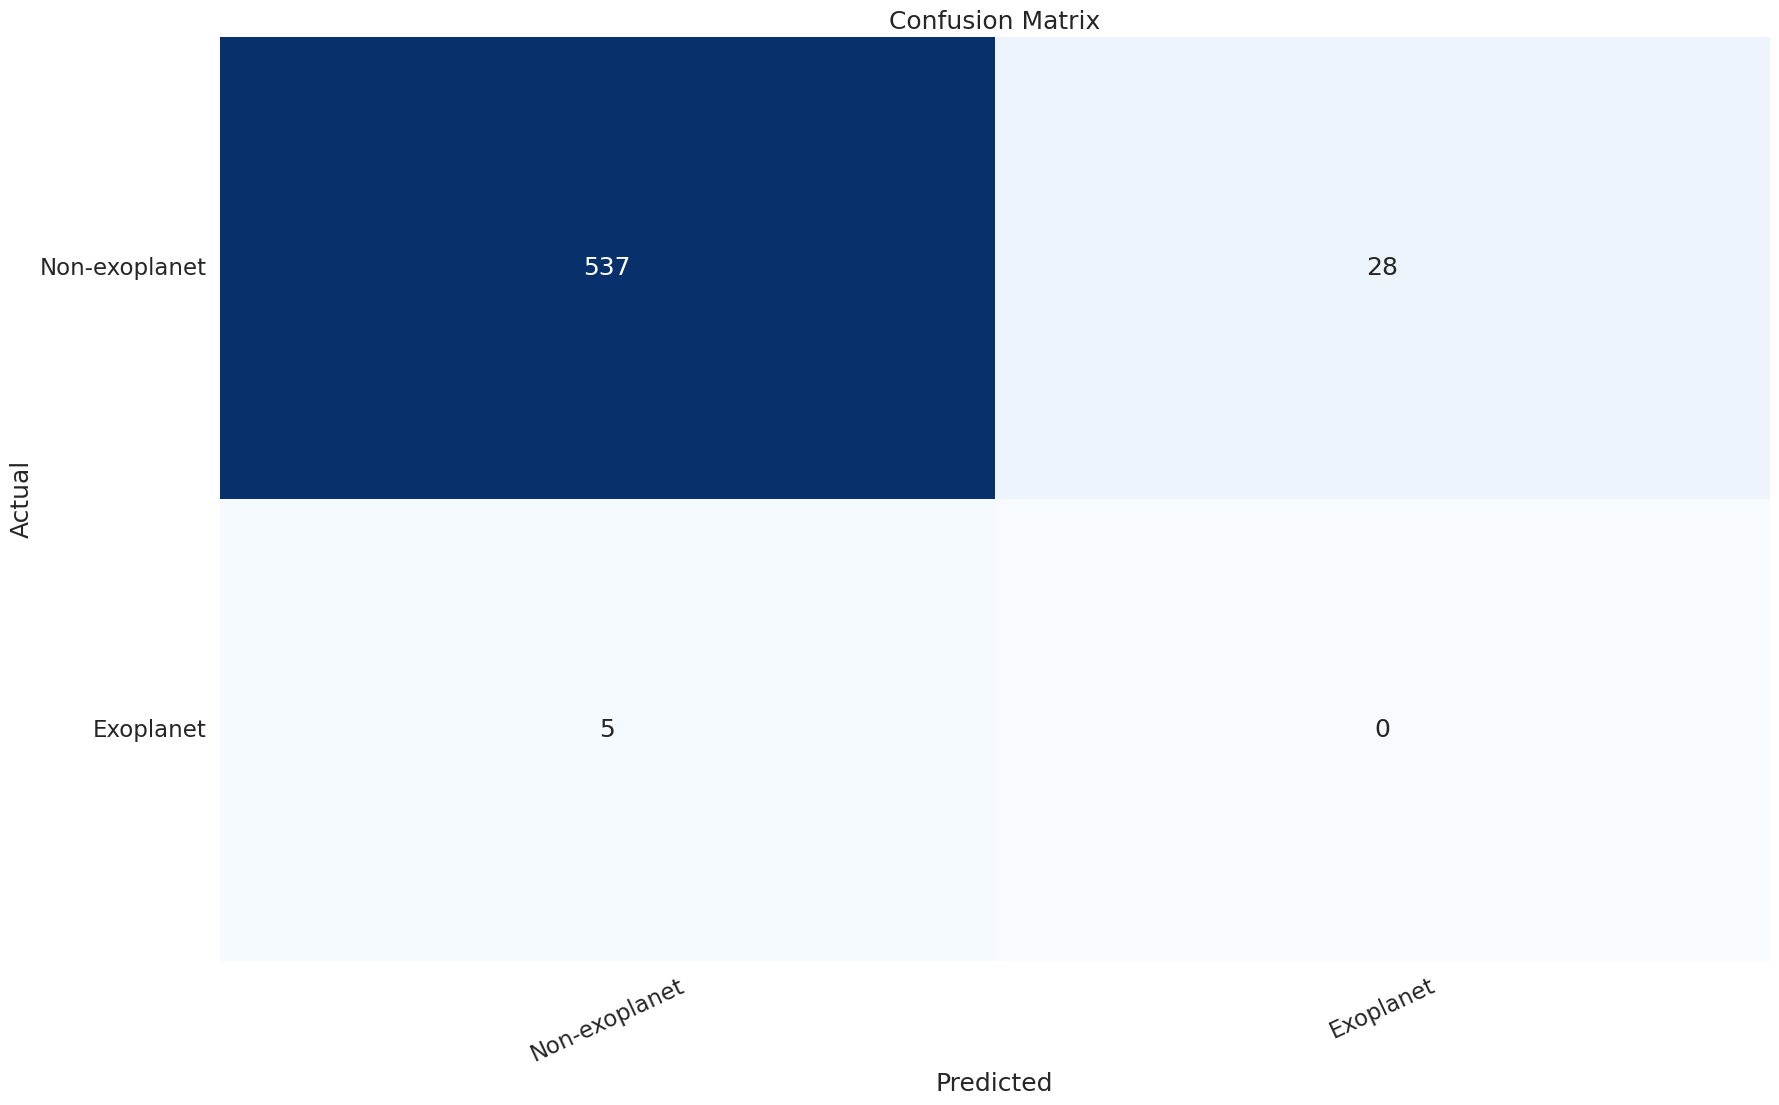

In [ ]:
# Generate the confusion matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_binary)

# Set the font scale
sns.set(font_scale=1.5)

# Plot the heatmap
plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)
plt.xticks(np.arange(2)+.5, class_names, rotation=25)
plt.yticks(np.arange(2)+.5, class_names, rotation=0)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
model.evaluate(x_test,y_test)

KeyboardInterrupt: 

In [ ]:
# Get the predicted class indices using model.predict and np.argmax
y_pred_indices = np.argmax(model_lstm.predict(x_test), axis=1)

# Get the class names from the y_train dataset
class_names=['Non-exoplanet','Exoplanet']

# Generate and print the classification report
print(classification_report(y_test, y_pred_indices, target_names=class_names))

18/18 [==============================] - 6s 233ms/step
               precision    recall  f1-score   support

Non-exoplanet       0.99      0.97      0.98       565
    Exoplanet       0.00      0.00      0.00         5

     accuracy                           0.96       570
    macro avg       0.50      0.49      0.49       570
 weighted avg       0.98      0.96      0.97       570



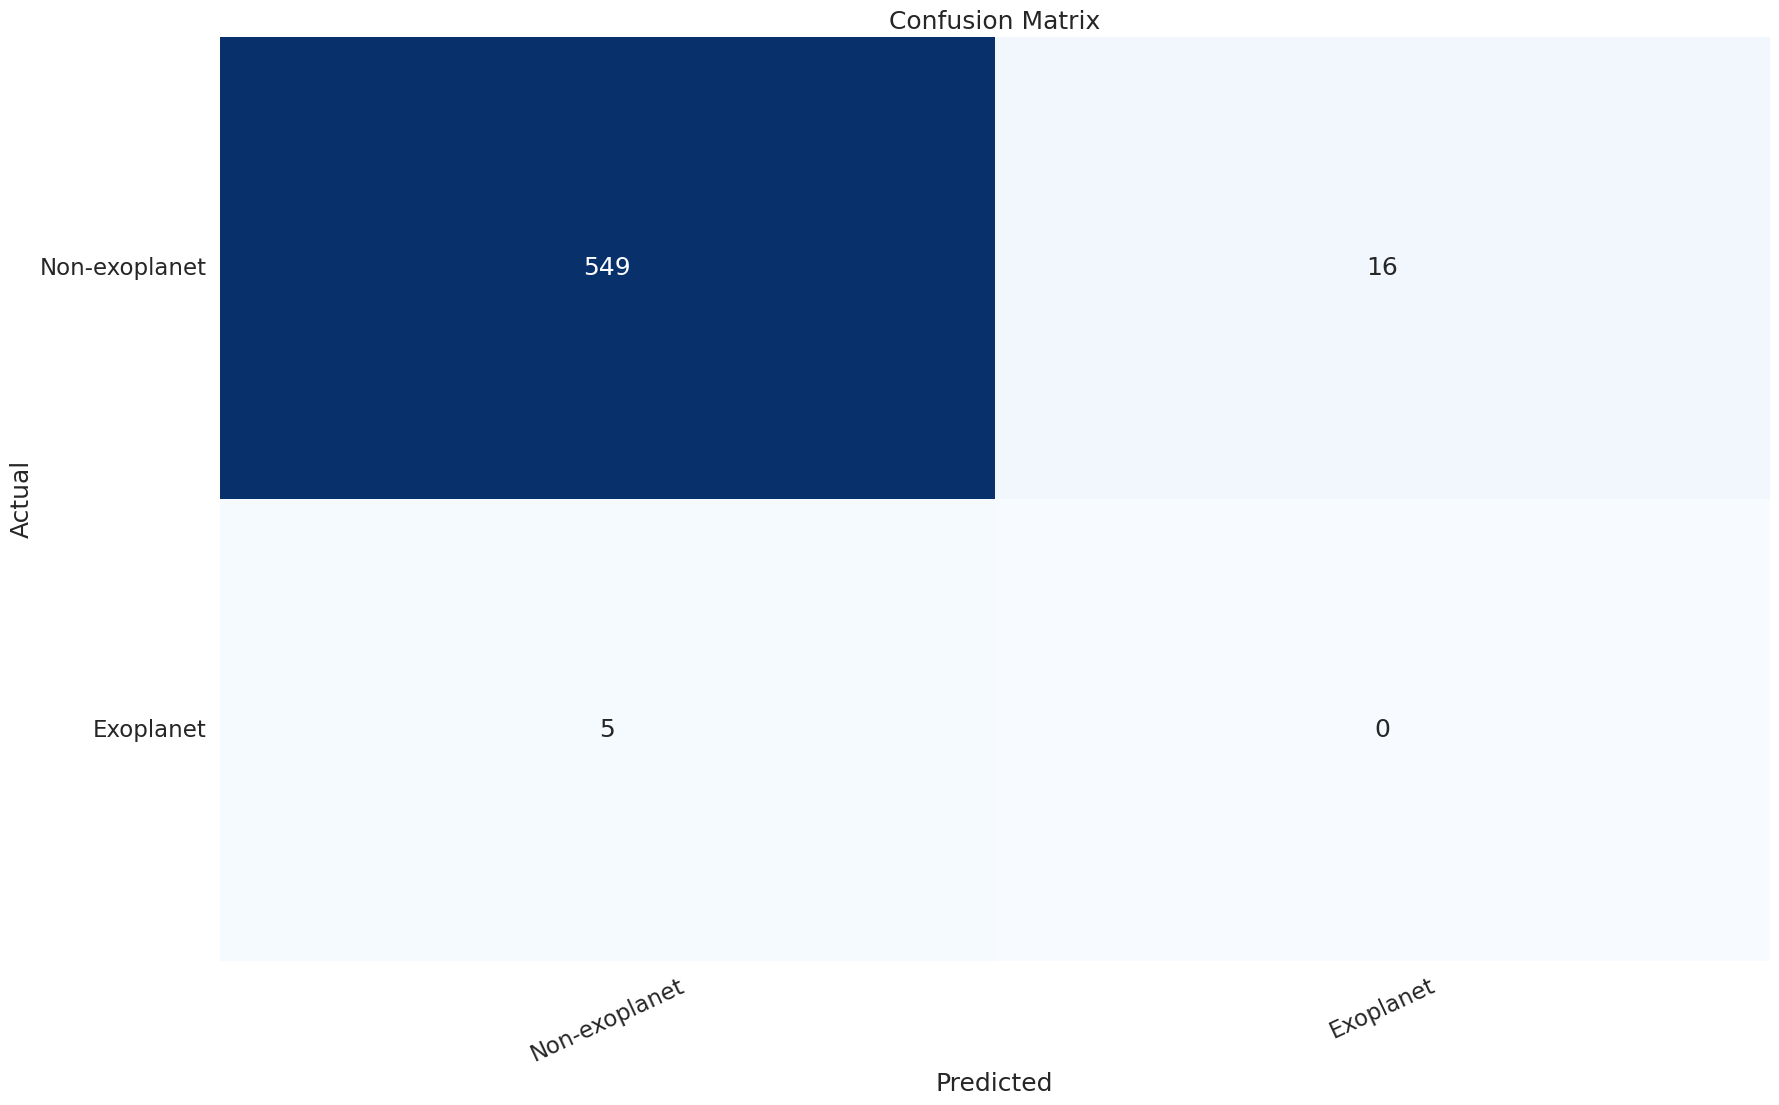

"plt.savefig('temp_plot.jpeg')\ntemp_plot = Image.open('temp_plot.jpeg')\ntemp_plot.save('acc_loss_1.jpeg')\ntemp_plot.close()\nos.remove('temp_plot.jpeg')"

In [ ]:
# Generate the confusion matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_indices)

# Set the font scale
sns.set(font_scale=1.5)

# Plot the heatmap
plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)
plt.xticks(np.arange(2)+.5, class_names, rotation=25)
plt.yticks(np.arange(2)+.5, class_names, rotation=0)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
'''plt.savefig('temp_plot.jpeg')
temp_plot = Image.open('temp_plot.jpeg')
temp_plot.save('acc_loss_1.jpeg')
temp_plot.close()
os.remove('temp_plot.jpeg')'''

# Evaluate model on test data

In [ ]:
model = keras.models.load_model("best_model.keras")

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test accuracy", test_acc)
print("Test loss", test_loss)

OSError: No file or directory found at best_model.keras

# Plot the model's training and validation loss

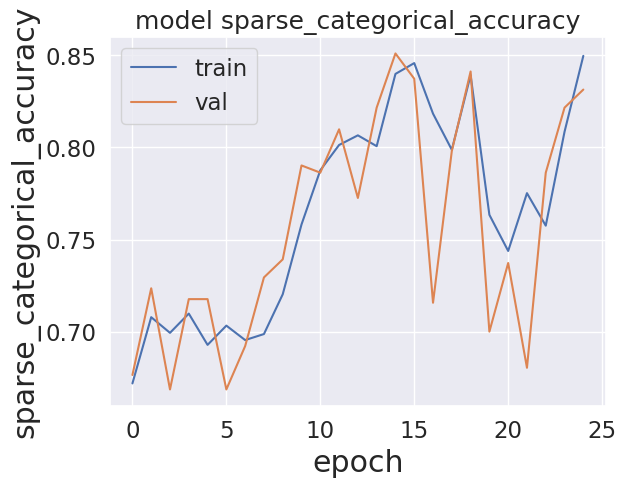

In [ ]:
metric = "sparse_categorical_accuracy"
plt.figure()
plt.plot(history.history[metric])
plt.plot(history.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()

*Etar pore oporer code ta copy kore (ADASYN+OSS) e apply koris dakh kichu change ase kina. Etar niche koris.Oporer ta run koris epoch=100 kore ar early stoping marbi. Confusion matrix tao print koriye dis.*

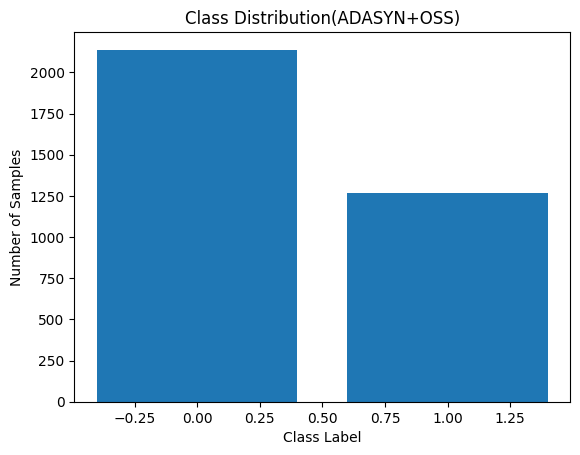

In [ ]:
import matplotlib.pyplot as plt

# Calculate class distribution
class_counts = np.bincount(y_train_adasyn_oss.flatten().astype(int))

# Plot class distribution
plt.bar(np.unique(y_train_adasyn_oss.flatten()), class_counts)
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.title('Class Distribution(ADASYN+OSS)')
plt.show()

In [ ]:
# Adding the validation set
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, stratify=y_train,
                                                  test_size=0.3, random_state=123)

In [ ]:
print(X_train.shape)
print(X_val.shape)

(1897, 3197, 1)
(813, 3197, 1)


In [ ]:
# Reshaping the data

np.set_printoptions(threshold=np.inf)
X_train_r = np.expand_dims(X_train, axis=2)
X_val_r = np.expand_dims(X_val, axis=2)
X_test = np.expand_dims(X_test, axis=2)

In [ ]:
print(X_train_r.shape)
print(X_test.shape)

(1897, 3197, 1, 1)
(570, 3197, 1)


In [ ]:
def batch_generator(X_train, y_train, batch_size=32):
    """
    Generates batches of training data with equal number of positive and
    negative samples, and rotates them randomly in time to augment the data
    """
    half_batch = batch_size // 2
    X_batch = np.empty((batch_size, X_train.shape[1], X_train.shape[2]), dtype='float32')
    y_batch = np.empty((batch_size, y_train.shape[1], dtype='float32')

    #Get the indices of positive(exoplanet) and negative(non-exoplanet) samples in the training data.
    yes_idx = np.where(y_train[:,0] == 1.)[0]
    non_idx = np.where(y_train[:,0] == 0.)[0]

    while True:
        np.random.shuffle(yes_idx)
        np.random.shuffle(non_idx)

        X_batch[:half_batch] = X_train[yes_idx[:half_batch]]
        X_batch[half_batch:] = X_train[non_idx[half_batch:batch_size]]
        y_batch[:half_batch] = y_train[yes_idx[:half_batch]]
        y_batch[half_batch:] = y_train[non_idx[half_batch:batch_size]]

        for i in range(batch_size):
            sz = np.random.randint(X_batch.shape[1])
            X_batch[i] = np.roll(X_batch[i], sz, axis = 0)

        yield X_batch, y_batch

In [ ]:
# Creating the model
ip = Input(shape=(3197, 1))

# KNN

# SVM

# Decision Tree

# Random Forest
\

In [ ]:
# 1D-CNN
y = Conv1D(filters=16, kernel_size=11, activation='relu')(ip)
y = MaxPool1D(strides=4)(y)
y = BatchNormalization()(y)
y = Conv1D(filters=32, kernel_size=11, activation='relu')(y)
y = MaxPool1D(strides=4)(y)
y = BatchNormalization()(y)
y = Conv1D(filters=64, kernel_size=11, activation='relu')(y)
y = MaxPool1D(strides=4)(y)
# y = BatchNormalization()(y)
# y = Conv1D(filters=128, kernel_size=11, activation='relu')(y)
# y = MaxPool1D(strides=4)(y)
y = Flatten()(y)
y = Dropout(0.25)(y)
y = Dense(64, activation='relu')(y)

#Simple CNN

In [ ]:
out = Dense(1, activation='sigmoid')(y)
model_cnn = Model(ip,out)
model_cnn.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 3197, 1)]         0         
                                                                 
 conv1d (Conv1D)             (None, 3187, 16)          192       
                                                                 
 max_pooling1d (MaxPooling1  (None, 797, 16)           0         
 D)                                                              
                                                                 
 batch_normalization (Batch  (None, 797, 16)           64        
 Normalization)                                                  
                                                                 
 conv1d_1 (Conv1D)           (None, 787, 32)           5664      
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 197, 32)           0     

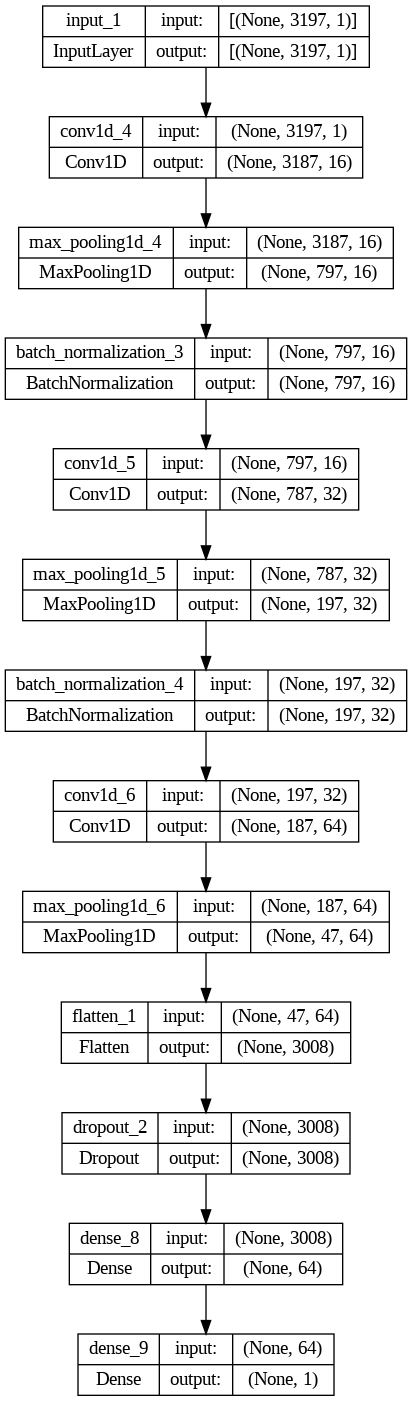

In [ ]:
from tensorflow.keras.utils import plot_model
# Plot the model architecture
plot_model(model_cnn, to_file='/content/drive/MyDrive/Dataset/Outputs/model_cnn.png', show_shapes=True, show_layer_names=True)


In [ ]:
model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
EarlyStopping=keras.callbacks.EarlyStopping(verbose=1, patience=20, monitor="accuracy", mode="max",restore_best_weights=True)


'''model_cnn.fit_generator(batch_generator(X_train_r, y_train, 32),
                           validation_data=(X_val_r, y_val),
                           epochs=100,
                           steps_per_epoch=X_train_r.shape[1]//32,
                           callbacks=[EarlyStopping],
                           verbose=1)'''

history = model_cnn.fit(X_train, y_train, batch_size=32, epochs = 100, validation_data=(X_val,y_val), callbacks = [EarlyStopping])

Epoch 1/100
60/60 [==============================] - 10s 18ms/step - loss: 0.1924 - accuracy: 0.9141 - val_loss: 0.2208 - val_accuracy: 0.9779
Epoch 2/100
60/60 [==============================] - 0s 8ms/step - loss: 0.0203 - accuracy: 0.9958 - val_loss: 0.1024 - val_accuracy: 0.9963
Epoch 3/100
60/60 [==============================] - 1s 9ms/step - loss: 0.0073 - accuracy: 0.9984 - val_loss: 0.0491 - val_accuracy: 0.9938
Epoch 4/100
60/60 [==============================] - 1s 9ms/step - loss: 0.0086 - accuracy: 0.9979 - val_loss: 0.0192 - val_accuracy: 0.9963
Epoch 5/100
60/60 [==============================] - 0s 8ms/step - loss: 0.0025 - accuracy: 0.9995 - val_loss: 0.0095 - val_accuracy: 0.9975
Epoch 6/100
60/60 [==============================] - 1s 9ms/step - loss: 0.0029 - accuracy: 0.9984 - val_loss: 0.0075 - val_accuracy: 0.9975
Epoch 7/100
60/60 [==============================] - 1s 9ms/step - loss: 0.0010 - accuracy: 1.0000 - val_loss: 0.0042 - val_accuracy: 0.9975
Epoch 8/100

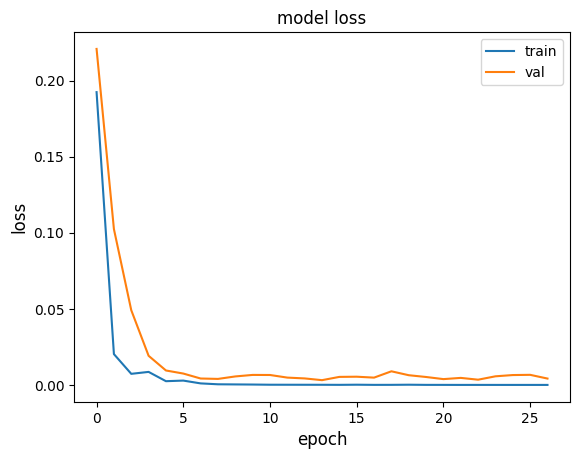

In [ ]:
metric = "loss"
plt.figure()
plt.plot(history.history[metric])
plt.plot(history.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()

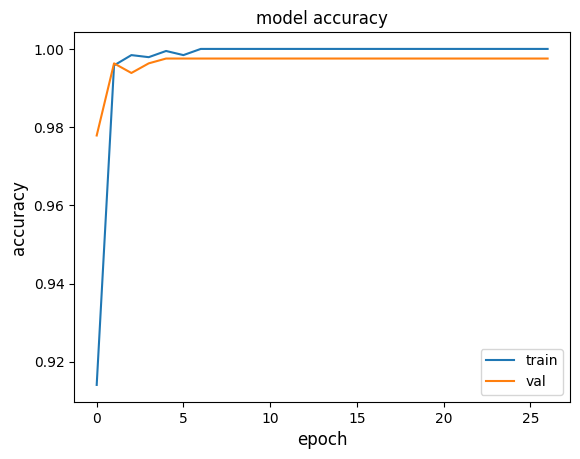

In [ ]:
metric = "accuracy"
plt.figure()
plt.plot(history.history[metric])
plt.plot(history.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()

In [ ]:
print(y_pred_indices)

[[3.58400762e-01]
 [5.08172363e-02]
 [9.25832272e-01]
 [9.62155468e-07]
 [1.77432401e-06]
 [1.81805293e-09]
 [7.61106946e-08]
 [2.13689049e-07]
 [1.80855650e-08]
 [1.94928393e-10]
 [4.97398123e-09]
 [9.82594839e-11]
 [6.89419943e-09]
 [1.45178927e-08]
 [3.57683966e-10]
 [1.70322467e-09]
 [4.19039026e-09]
 [3.12770054e-09]
 [6.82930101e-12]
 [1.54088298e-08]
 [9.14206339e-06]
 [1.24540126e-11]
 [3.09497364e-06]
 [4.70240730e-06]
 [4.47006460e-10]
 [1.16935901e-08]
 [2.28418529e-08]
 [1.96155452e-05]
 [1.17456445e-07]
 [8.01931776e-07]
 [5.07725284e-09]
 [1.00567055e-09]
 [9.45415968e-10]
 [1.25706421e-07]
 [8.02136191e-10]
 [1.75811887e-09]
 [1.35796985e-10]
 [1.86981297e-09]
 [5.24033332e-08]
 [1.38184878e-05]
 [2.14206319e-09]
 [2.12600049e-10]
 [1.12287940e-04]
 [1.19296672e-07]
 [2.97423114e-10]
 [1.60682329e-10]
 [3.19471134e-08]
 [1.15700538e-09]
 [1.22806186e-05]
 [2.69091572e-07]
 [1.55803204e-09]
 [2.25263246e-11]
 [2.81492767e-08]
 [5.89786664e-09]
 [7.60426474e-06]
 [8.275568

In [ ]:
# Get the predicted class indices using model.predict and np.argmax
y_pred_indices = model_cnn.predict(x_test)
import numpy as np

# Assuming y_pred_indices is a numpy array with continuous values
# Thresholding operation: if less than 0.5, set to 0; otherwise, set to 1
y_pred_binary = np.where(y_pred_indices < 0.5, 0, 1)

# Get the class names from the y_train dataset
class_names=['Non-exoplanet','Exoplanet']

# Generate and print the classification report
print(classification_report(y_test, y_pred_binary, target_names=class_names))

18/18 [==============================] - 0s 5ms/step
               precision    recall  f1-score   support

Non-exoplanet       0.99      1.00      1.00       565
    Exoplanet       0.50      0.20      0.29         5

     accuracy                           0.99       570
    macro avg       0.75      0.60      0.64       570
 weighted avg       0.99      0.99      0.99       570



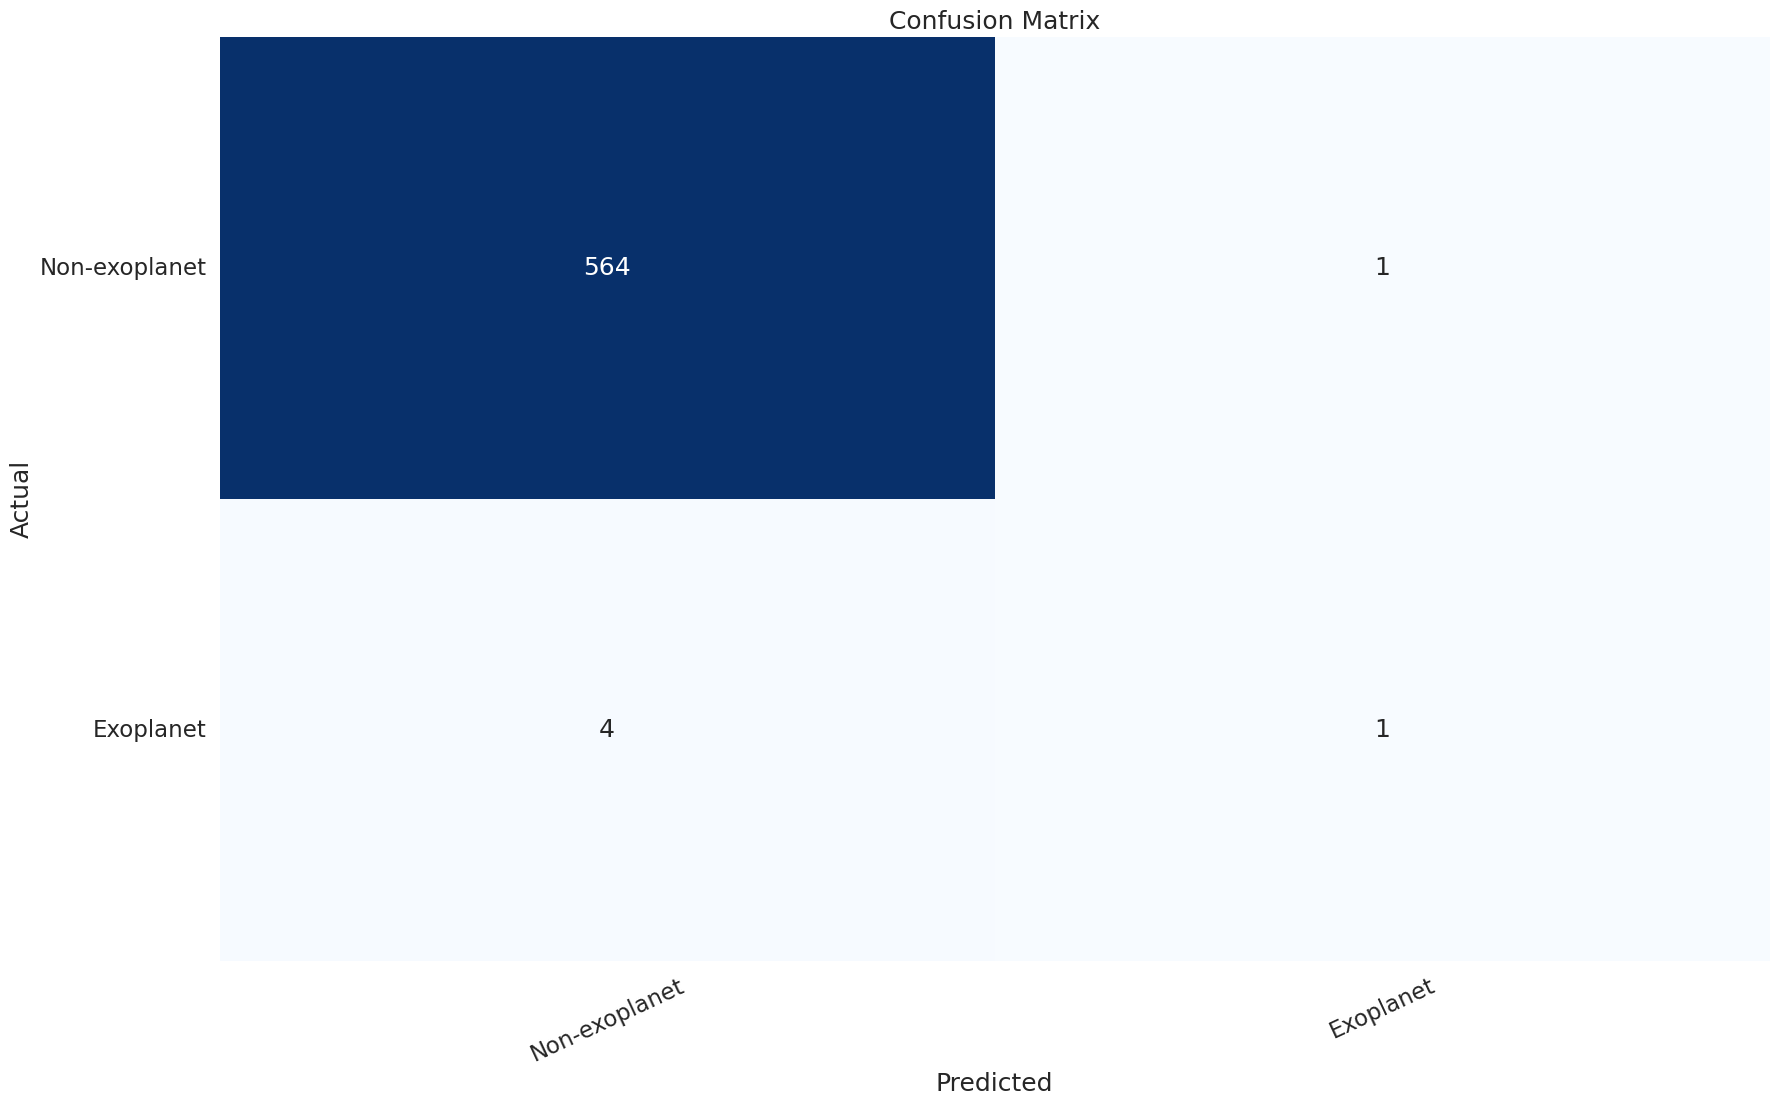

In [ ]:
# Generate the confusion matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_binary)

# Set the font scale
sns.set(font_scale=1.5)

# Plot the heatmap
plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)
plt.xticks(np.arange(2)+.5, class_names, rotation=25)
plt.yticks(np.arange(2)+.5, class_names, rotation=0)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
y_pred = model_cnn.predict(x=X_test)

18/18 [==============================] - 0s 3ms/step


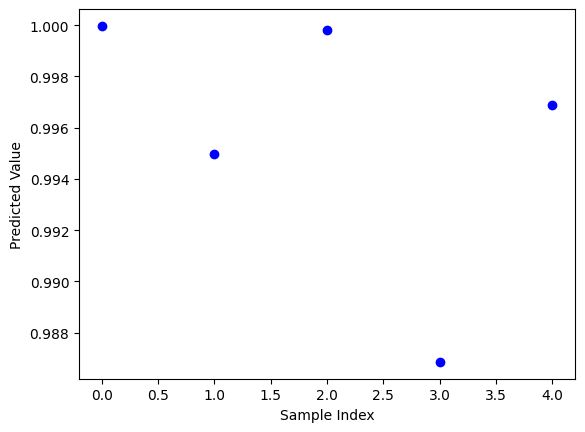

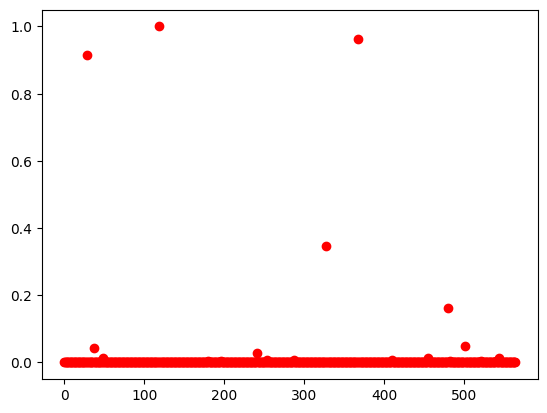

In [ ]:
non_idx = np.where(y_test[:,0] == 0.)[0]
yes_idx = np.where(y_test[:,0] == 1.)[0]
plt.plot([y_pred[i] for i in yes_idx], 'bo', label='Positive Class Predictions')
plt.xlabel('Sample Index')
plt.ylabel('Predicted Value')
plt.show()
plt.plot([y_pred[i] for i in non_idx], 'ro', label='Negative Class Predictions')
plt.show()

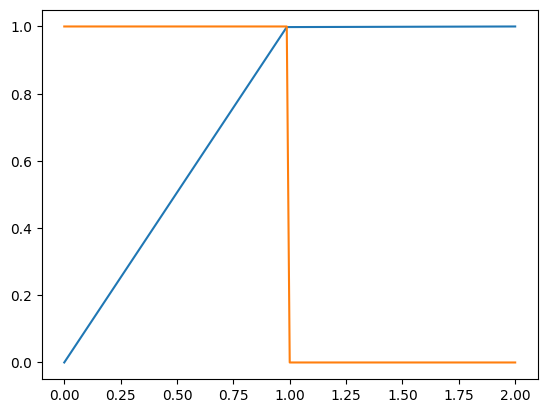

Crossover at 0.99 with specificity 1.00


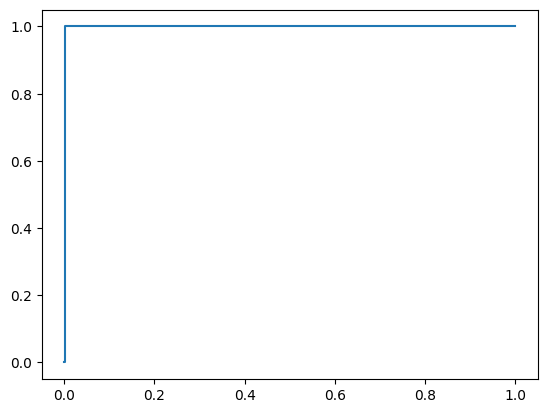

ROC area under curve is 1.00


In [ ]:
#ROC Area under curve
y_true = (y_test[:, 0] + 0.5).astype("int")
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
plt.plot(thresholds, 1.-fpr)
plt.plot(thresholds, tpr)
plt.show()
crossover_index = np.min(np.where(1.-fpr <= tpr))
crossover_cutoff = thresholds[crossover_index]
crossover_specificity = 1.-fpr[crossover_index]
print("Crossover at {0:.2f} with specificity {1:.2f}".format(crossover_cutoff, crossover_specificity))
plt.plot(fpr, tpr)
plt.show()
print("ROC area under curve is {0:.2f}".format(roc_auc_score(y_true, y_pred)))

In [ ]:
predthr = np.where(y_pred > 0.5, 1, 0)
print(classification_report(y_test, predthr))

              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00       565
         1.0       0.62      1.00      0.77         5

    accuracy                           0.99       570
   macro avg       0.81      1.00      0.88       570
weighted avg       1.00      0.99      1.00       570



In [ ]:
print(confusion_matrix(y_test, predthr))

[[562   3]
 [  0   5]]


# CNN+LSTM


In [ ]:
ip= X_test.shape

In [ ]:
# LSTM
x = Permute((2, 1))(ip)
x = LSTM(16, return_sequences=True)(x)
x = LSTM(32, return_sequences=True)(x)
# x = LSTM(64, return_sequences=True)(x)
# x = LSTM(128)(x)
x = LSTM(64)(x)
x = Dropout(0.25)(x)

In [ ]:
# 1D-CNN
y = Conv1D(filters=16, kernel_size=11, activation='relu')(ip)
y = MaxPool1D(strides=4)(y)
y = BatchNormalization()(y)
y = Conv1D(filters=32, kernel_size=11, activation='relu')(y)
y = MaxPool1D(strides=4)(y)
y = BatchNormalization()(y)
y = Conv1D(filters=64, kernel_size=11, activation='relu')(y)
y = MaxPool1D(strides=4)(y)
# y = BatchNormalization()(y)
# y = Conv1D(filters=128, kernel_size=11, activation='relu')(y)
# y = MaxPool1D(strides=4)(y)
y = Flatten()(y)
y = Dropout(0.25)(y)
y = Dense(64, activation='relu')(y)

In [ ]:
#Concatenate
x = concatenate([x, y])
x = Dense(32, activation='relu')(x)
out = Dense(2, activation='softmax')(x)
model_cnn_lstm = Model(ip, out)
model_cnn_lstm.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 3197, 1)]            0         []                            
                                                                                                  
 conv1d (Conv1D)             (None, 3187, 16)             192       ['input_1[0][0]']             
                                                                                                  
 max_pooling1d (MaxPooling1  (None, 797, 16)              0         ['conv1d[0][0]']              
 D)                                                                                               
                                                                                                  
 batch_normalization (Batch  (None, 797, 16)              64        ['max_pooling1d[0][0]']   

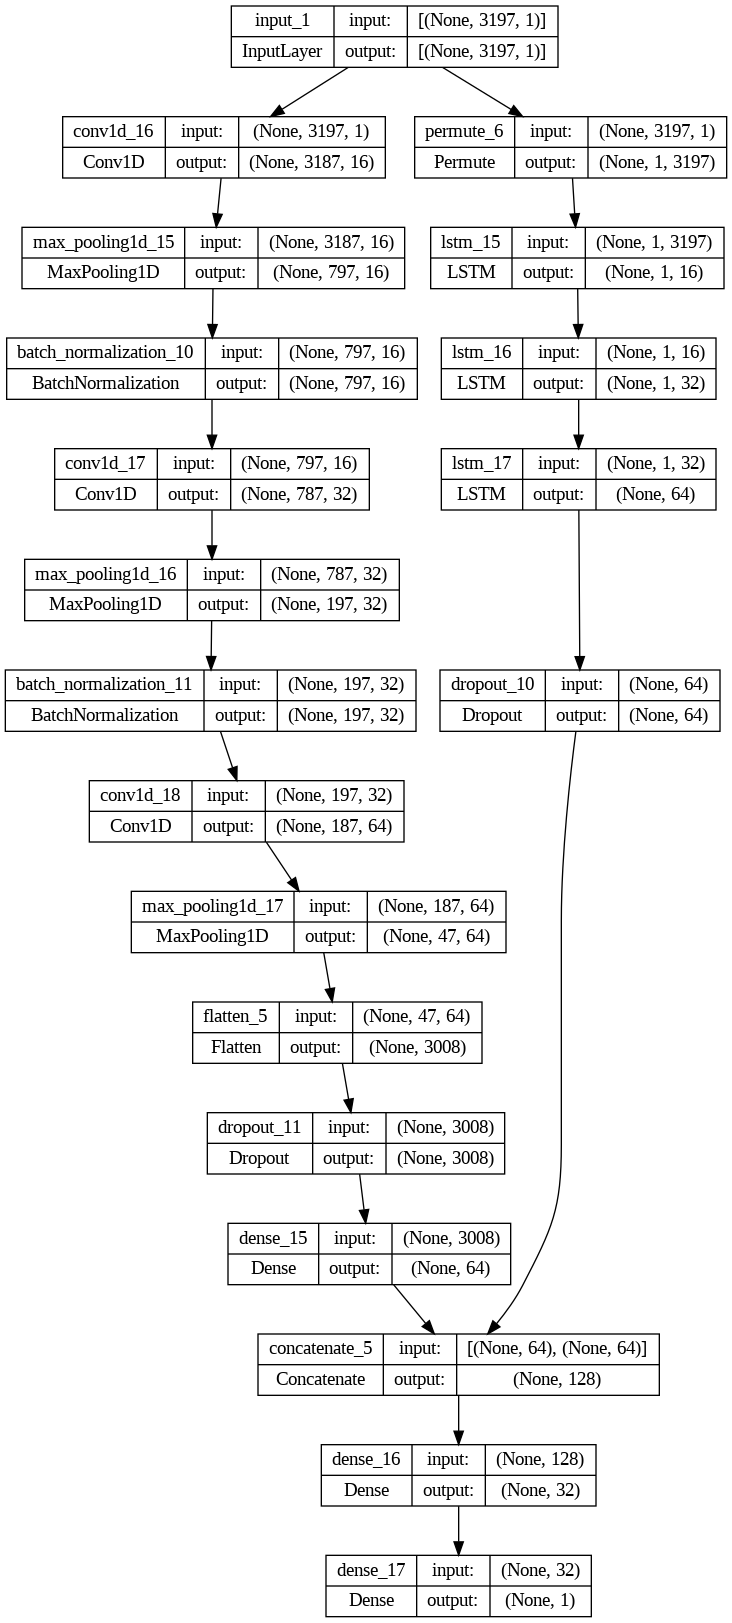

In [ ]:
from tensorflow.keras.utils import plot_model
# Plot the model architecture
plot_model(model_cnn_lstm, to_file='/content/drive/MyDrive/Dataset/Outputs/model_cnn_lstm.png', show_shapes=True, show_layer_names=True)


In [ ]:
#model_cnn_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
'''model_cnn_lstm.fit((X_train, y_train, 32),
                           validation_data=(X_val, y_val),
                           epochs=20,
                           steps_per_epoch=X_train.shape[1]//32,
                           verbose=1)'''

epochs = 100
batch_size = 32
EarlyStopping=keras.callbacks.EarlyStopping(verbose=1, patience=20, monitor="val_sparse_categorical_accuracy", mode="max",restore_best_weights=True)

model_cnn_lstm.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"]
)
history = model_cnn_lstm.fit(
    X_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[EarlyStopping],
    #validation_split=0.2
    validation_data=(X_val,y_val)
)

Epoch 1/100
60/60 [==============================] - 13s 31ms/step - loss: 0.0067 - sparse_categorical_accuracy: 0.9984 - val_loss: 0.0058 - val_sparse_categorical_accuracy: 0.9988
Epoch 2/100
60/60 [==============================] - 1s 12ms/step - loss: 0.0303 - sparse_categorical_accuracy: 0.9900 - val_loss: 0.1702 - val_sparse_categorical_accuracy: 0.9607
Epoch 3/100
60/60 [==============================] - 1s 11ms/step - loss: 0.0134 - sparse_categorical_accuracy: 0.9953 - val_loss: 0.0129 - val_sparse_categorical_accuracy: 0.9975
Epoch 4/100
60/60 [==============================] - 1s 12ms/step - loss: 0.0043 - sparse_categorical_accuracy: 0.9984 - val_loss: 0.0117 - val_sparse_categorical_accuracy: 0.9975
Epoch 5/100
60/60 [==============================] - 1s 14ms/step - loss: 0.0010 - sparse_categorical_accuracy: 0.9995 - val_loss: 0.0080 - val_sparse_categorical_accuracy: 0.9975
Epoch 6/100
60/60 [==============================] - 1s 13ms/step - loss: 1.8356e-04 - sparse_categ

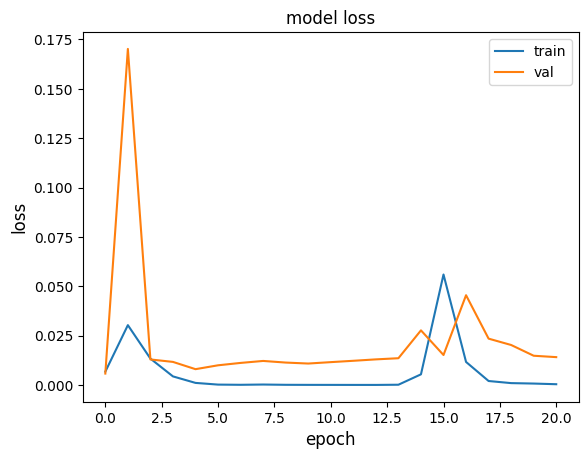

In [ ]:
metric = "loss"
plt.figure()
plt.plot(history.history[metric])
plt.plot(history.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()

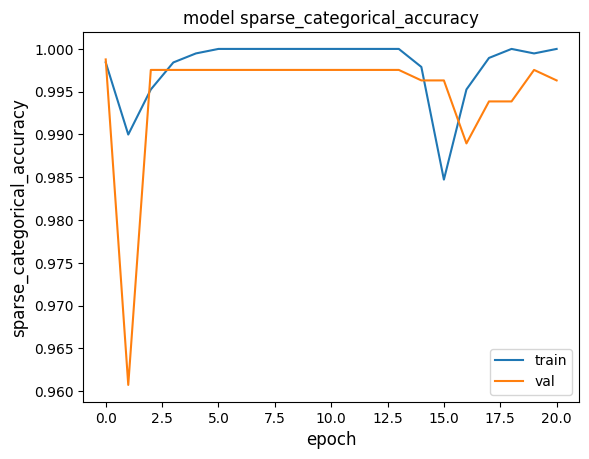

In [ ]:
metric = "sparse_categorical_accuracy"
plt.figure()
plt.plot(history.history[metric])
plt.plot(history.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()

In [ ]:
# Get the predicted class indices using model.predict and np.argmax
y_pred_indices = np.argmax(model_cnn_lstm.predict(x_test), axis=1)

# Get the class names from the y_train dataset
class_names=['Non-exoplanet','Exoplanet']

# Generate and print the classification report
print(classification_report(y_test, y_pred_indices, target_names=class_names))

18/18 [==============================] - 2s 14ms/step
               precision    recall  f1-score   support

Non-exoplanet       0.99      1.00      0.99       565
    Exoplanet       0.00      0.00      0.00         5

     accuracy                           0.99       570
    macro avg       0.50      0.50      0.50       570
 weighted avg       0.98      0.99      0.99       570



In [ ]:
y_pred = model_cnn_lstm.predict(x=X_test)

18/18 [==============================] - 1s 4ms/step


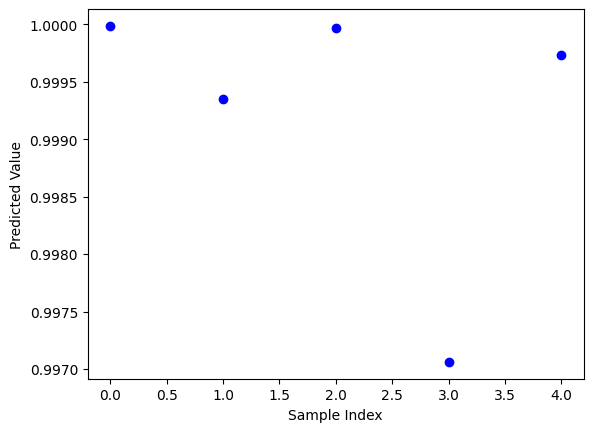

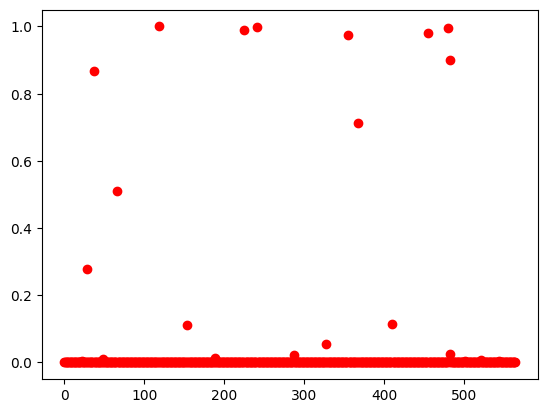

In [ ]:
non_idx = np.where(y_test[:,0] == 0.)[0]
yes_idx = np.where(y_test[:,0] == 1.)[0]
plt.plot([y_pred[i] for i in yes_idx], 'bo', label='Positive Class Predictions')
plt.xlabel('Sample Index')
plt.ylabel('Predicted Value')
plt.show()
plt.plot([y_pred[i] for i in non_idx], 'ro', label='Negative Class Predictions')
plt.show()

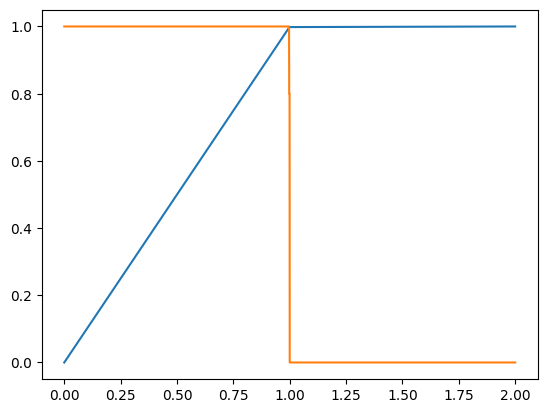

Crossover at 1.00 with specificity 1.00


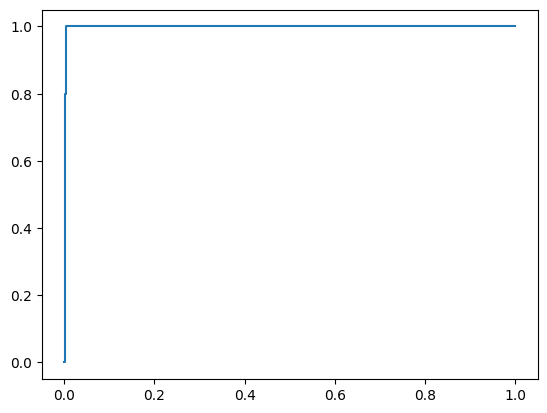

ROC area under curve is 1.00


In [ ]:
#ROC Area under curve
y_true = (y_test[:, 0] + 0.5).astype("int")
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
plt.plot(thresholds, 1.-fpr)
plt.plot(thresholds, tpr)
plt.show()
crossover_index = np.min(np.where(1.-fpr <= tpr))
crossover_cutoff = thresholds[crossover_index]
crossover_specificity = 1.-fpr[crossover_index]
print("Crossover at {0:.2f} with specificity {1:.2f}".format(crossover_cutoff, crossover_specificity))
plt.plot(fpr, tpr)
plt.show()
print("ROC area under curve is {0:.2f}".format(roc_auc_score(y_true, y_pred)))

In [ ]:
predthr = np.where(y_pred > 0.5, 1, 0)
print(classification_report(y_test, predthr))

              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99       565
         1.0       0.33      1.00      0.50         5

    accuracy                           0.98       570
   macro avg       0.67      0.99      0.75       570
weighted avg       0.99      0.98      0.99       570



In [ ]:
print(confusion_matrix(y_test, predthr))

[[555  10]
 [  0   5]]
